# Lateral Eye Movement — MATLAB runica ICA Pipeline

**Pipeline**: Load `.set` → FIR filter (0.5–40 Hz) → **MATLAB `runica.m`** (Extended Infomax via `matlab.engine`) → Stacked IC plot with event backgrounds

**Why MATLAB runica?**  
MNE's infomax and EEGLAB's runica produce different IC decompositions (different random seeds, implementation details). By calling EEGLAB's actual `runica.m` through the MATLAB Engine for Python, we get **exact EEGLAB-matching** ICA weights and activations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hdf5storage
import mne
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 1. Load Dataset
- **hdf5storage** → event labels (eye-l, eye-r, etc.)
- **MNE** → EEG signal data

In [2]:
# ── Load metadata + events via hdf5storage ──
mat = hdf5storage.loadmat('without_eog_channels.set')

nbchan = int(mat['nbchan'].item())
pnts   = int(mat['pnts'].item())
trials = int(mat['trials'].item())
srate  = int(mat['srate'].item())

chanlocs = mat['chanlocs'][0]
ch_names = [str(ch['labels'][0]) for ch in chanlocs]

print(f'Channels: {nbchan}  |  Points/epoch: {pnts}  |  Epochs: {trials}  |  Fs: {srate} Hz')
print(f'Epoch duration: {pnts/srate:.1f} s  |  Total samples: {trials*pnts:,}')

# ── Parse ALL events ──
events = []
for ev in mat['event'][0]:
    events.append({
        'latency':  ev['latency'][0, 0] if ev['latency'].size  else 0,
        'type':     str(ev['type'][0])   if ev['type'].size     else '',
        'epoch':    int(ev['epoch'][0,0]) if ev['epoch'].size   else 0,
        'duration': ev['duration'][0, 0] if ev['duration'].size else 0,
    })

eye_types = sorted({e['type'] for e in events})
print(f'Total events: {len(events)}  |  Types: {eye_types}')

# ── Load EEG data via MNE ──
epochs_mne = mne.io.read_epochs_eeglab('without_eog_channels.set', verbose=False)
print(f'MNE epochs shape: {epochs_mne.get_data().shape}')

Channels: 58  |  Points/epoch: 1600  |  Epochs: 52  |  Fs: 200 Hz
Epoch duration: 8.0 s  |  Total samples: 83,200
Total events: 381  |  Types: ['1', '2', '3', '4', 'blink', 'eye-d', 'eye-l', 'eye-r', 'eye-u', 'fixation']
MNE epochs shape: (52, 58, 1600)


## 2. FIR Filter (0.5 – 40 Hz) — All Epochs

In [3]:
# Filter all epochs at once (matching EEGLAB pop_eegfiltnew)
epochs_filt = epochs_mne.copy().filter(
    l_freq=0.5, h_freq=40.0,
    method='fir', fir_design='firwin', phase='zero',
    verbose=False
)

filt_data = epochs_filt.get_data()  # (n_epochs, n_channels, n_samples)
print(f'Filtered data shape: {filt_data.shape}')
print(f'Range: [{filt_data.min():.4f}, {filt_data.max():.4f}]')

Filtered data shape: (52, 58, 1600)
Range: [-0.0002, 0.0004]


## 3. ICA — Load Pre-computed EEGLAB Weights

Loads `icaweights` and `icasphere` from `without_eog_channels_Filter_ExtRunica_ICA.set` — these are the **exact weights** EEGLAB computed with `runica('extended', 1)`.  
No need to re-run runica; just compute activations: `icaact = icaweights * icasphere * data_µV`

In [4]:
# ── Load pre-computed ICA weights from EEGLAB .set file ──
ica_mat = hdf5storage.loadmat('without_eog_channels_Filter_ExtRunica_ICA.set')

icaweights = np.array(ica_mat['icaweights'])  # (58, 58)
icasphere  = np.array(ica_mat['icasphere'])   # (58, 58)
icawinv    = np.array(ica_mat['icawinv'])      # (58, 58)

print(f'Loaded EEGLAB pre-computed ICA weights from Filter_ExtRunica_ICA.set')
print(f'  icaweights: {icaweights.shape}')
print(f'  icasphere:  {icasphere.shape}')
print(f'  icawinv:    {icawinv.shape}')

# ── Compute IC activations on filtered data ──
# EEGLAB convention: data in µV
filt_data_all = epochs_filt.get_data()  # (52, 58, 1600) in Volts
data_uv = np.concatenate([filt_data_all[i] for i in range(trials)], axis=1) * 1e6  # → µV
print(f'  Data: {data_uv.shape} in µV')

W_combined = icaweights @ icasphere
icaact = W_combined @ data_uv  # (58, 83200)
print(f'  icaact: {icaact.shape}')

# ── Reshape into epochs ──
ic_all = icaact.reshape(nbchan, trials, pnts).transpose(1, 0, 2)  # (52, 58, 1600)
print(f'  ic_all: {ic_all.shape}  (epochs, ICs, samples)')

# ── Raw IC Statistics (first 6) ──
print(f'\nRaw IC Statistics (first 6):')
for ic in range(min(6, nbchan)):
    vals = icaact[ic]
    print(f'  IC{ic+1:>2d}: mean={np.mean(vals):>10.2f}  std={np.std(vals):>10.2f}  '
          f'min={np.min(vals):>12.2f}  max={np.max(vals):>12.2f}')

Loaded EEGLAB pre-computed ICA weights from Filter_ExtRunica_ICA.set
  icaweights: (58, 58)
  icasphere:  (58, 58)
  icawinv:    (58, 58)
  Data: (58, 83200) in µV
  icaact: (58, 83200)
  ic_all: (52, 58, 1600)  (epochs, ICs, samples)

Raw IC Statistics (first 6):
  IC 1: mean=      0.00  std=     12.34  min=      -75.39  max=      127.30
  IC 2: mean=      0.14  std=      6.14  min=     -139.17  max=       47.78
  IC 3: mean=      0.03  std=      2.97  min=      -14.02  max=       15.50
  IC 4: mean=      0.05  std=      2.81  min=      -11.78  max=       12.74
  IC 5: mean=      0.04  std=      2.54  min=      -34.73  max=       14.05
  IC 6: mean=      0.02  std=      2.11  min=      -10.04  max=        9.24


## 3.1 Weight Comparison — Fresh runica vs Pre-computed

Compute fresh ICA weights using MATLAB's `runica.m` and compare with the pre-computed weights to understand decomposition variability.

In [5]:
# ── Run fresh MATLAB runica and compare with pre-computed weights ──
import matlab.engine

print('Starting MATLAB engine...')
eng = matlab.engine.start_matlab()

# Add runica.m to MATLAB path (if needed)
runica_dir = r'D:\Bunker\BaseCamp\BrainComputerInterface\Lateral Eye Dataset'
eng.addpath(runica_dir, nargout=0)

# Prepare data for MATLAB (must be double, in µV)
data_matlab = matlab.double(data_uv.tolist())

print(f'\nRunning fresh runica on {data_uv.shape}...')
print('  (This may take 1-2 minutes)')

# Run runica with extended infomax (same as EEGLAB)
weights, sphere = eng.runica(data_matlab, 'extended', 1, nargout=2)

# Convert to numpy
fresh_weights = np.array(weights)
fresh_sphere = np.array(sphere)
fresh_combined = fresh_weights @ fresh_sphere

print(f'\n✓ Fresh runica complete')
print(f'  Fresh weights: {fresh_weights.shape}')
print(f'  Fresh sphere:  {fresh_sphere.shape}')

# ── Compare fresh vs pre-computed weights ──
print(f'\n━━━ Weight Comparison ━━━')

# 1. Matrix correlation (element-wise)
corr_weights = np.corrcoef(icaweights.flatten(), fresh_weights.flatten())[0, 1]
corr_sphere = np.corrcoef(icasphere.flatten(), fresh_sphere.flatten())[0, 1]
corr_combined = np.corrcoef(W_combined.flatten(), fresh_combined.flatten())[0, 1]

print(f'Matrix correlation (element-wise):')
print(f'  icaweights: {corr_weights:.4f}')
print(f'  icasphere:  {corr_sphere:.4f}')
print(f'  combined:   {corr_combined:.4f}')

# 2. MSE between matrices
mse_weights = np.mean((icaweights - fresh_weights) ** 2)
mse_sphere = np.mean((icasphere - fresh_sphere) ** 2)
mse_combined = np.mean((W_combined - fresh_combined) ** 2)

print(f'\nMSE (Mean Squared Error):')
print(f'  icaweights: {mse_weights:.6f}')
print(f'  icasphere:  {mse_sphere:.6f}')
print(f'  combined:   {mse_combined:.6f}')

# 3. Component-wise correlation (row-by-row)
# Each row represents one IC's mixing coefficients
row_corrs = []
for i in range(min(10, nbchan)):
    r = np.corrcoef(W_combined[i], fresh_combined[i])[0, 1]
    row_corrs.append(r)
    print(f'  IC{i+1:>2d} row correlation: {r:>7.4f}')

avg_row_corr = np.mean(row_corrs)
print(f'\nAverage row correlation (first 10 ICs): {avg_row_corr:.4f}')

# 4. Compute fresh activations
fresh_icaact = fresh_combined @ data_uv
fresh_ic_all = fresh_icaact.reshape(nbchan, trials, pnts).transpose(1, 0, 2)

# Compare IC activations (first epoch)
act_corr = np.corrcoef(ic_all[0].flatten(), fresh_ic_all[0].flatten())[0, 1]
print(f'\nIC activations correlation (epoch 1): {act_corr:.4f}')

print(f'\n{"="*50}')
print('Interpretation:')
print('  - Low correlation = ICA found different decomposition (expected)')
print('  - High correlation = Nearly identical decomposition (rare)')
print('  - runica is stochastic → different runs produce different ICs')

eng.quit()
print('\nMATLAB engine stopped.')

Starting MATLAB engine...

Running fresh runica on (58, 83200)...
  (This may take 1-2 minutes)

✓ Fresh runica complete
  Fresh weights: (58, 58)
  Fresh sphere:  (58, 58)

━━━ Weight Comparison ━━━
Matrix correlation (element-wise):
  icaweights: 0.2183
  icasphere:  1.0000
  combined:   0.1292

MSE (Mean Squared Error):
  icaweights: 0.019491
  icasphere:  0.000199
  combined:   0.886077
  IC 1 row correlation:  0.9999
  IC 2 row correlation:  0.9520
  IC 3 row correlation:  0.9451
  IC 4 row correlation:  0.8114
  IC 5 row correlation:  0.3798
  IC 6 row correlation: -0.0931
  IC 7 row correlation:  0.1838
  IC 8 row correlation:  0.5027
  IC 9 row correlation:  0.8933
  IC10 row correlation: -0.3058

Average row correlation (first 10 ICs): 0.5269

IC activations correlation (epoch 1): 0.1448

Interpretation:
  - Low correlation = ICA found different decomposition (expected)
  - High correlation = Nearly identical decomposition (rare)
  - runica is stochastic → different runs produ

## 4. ICA Validation

In [6]:
# ── ICA Validation (MATLAB runica weights) ──

# 1. Reconstruction: data ≈ icawinv @ icaact
recon_uv = icawinv @ icaact
mse = np.mean((data_uv - recon_uv) ** 2)
print(f'Reconstruction MSE (µV²): {mse:.2e}  {"PASS" if mse < 1e-4 else "FAIL"}')

# 2. Independence: IC cross-correlations on epoch 1
corr = np.corrcoef(ic_all[0])
np.fill_diagonal(corr, 0)
max_corr = np.max(np.abs(corr))
print(f'Max IC correlation:       {max_corr:.4f}  {"PASS" if max_corr < 0.3 else "WARN"}')

# 3. Matrix inversion: W_combined @ icawinv ≈ I
prod = W_combined @ icawinv
merr = np.mean((prod - np.eye(prod.shape[0])) ** 2)
print(f'W*Winv identity MSE:      {merr:.2e}  {"PASS" if merr < 1e-10 else "FAIL"}')

# 4. NaN/Inf check
has_bad = np.any(np.isnan(icaact)) or np.any(np.isinf(icaact))
print(f'NaN/Inf in activations:   {has_bad}  {"FAIL" if has_bad else "PASS"}')

Reconstruction MSE (µV²): 1.46e-25  PASS
Max IC correlation:       0.5009  WARN
W*Winv identity MSE:      3.25e-29  PASS
NaN/Inf in activations:   False  PASS


## 5. EEGLAB-Style Stacked IC Plot (eegplot scaling)

Shows multiple epochs concatenated with colored backgrounds.  
**Normalization**: EEGLAB "Norm" — divide each IC by its std (no mean subtraction).  
**Spacing**: Vertical offset between channel centres (like eegplot `'spacing', N`).

IC shape: (58, 8000)  |  Time: 0–40s  |  Spacing: 50
  IC1: raw µV [-28.0, 127.3]  |  std=13.37  |  norm [-2.09, 9.52]
  IC2: raw µV [-60.5, 29.9]  |  std=5.18  |  norm [-11.68, 5.78]
  IC3: raw µV [-14.0, 14.5]  |  std=3.16  |  norm [-4.44, 4.59]
  IC4: raw µV [-10.1, 11.4]  |  std=2.83  |  norm [-3.55, 4.02]
  IC5: raw µV [-12.7, 7.6]  |  std=2.38  |  norm [-5.33, 3.20]
  IC6: raw µV [-8.7, 7.2]  |  std=2.04  |  norm [-4.28, 3.55]


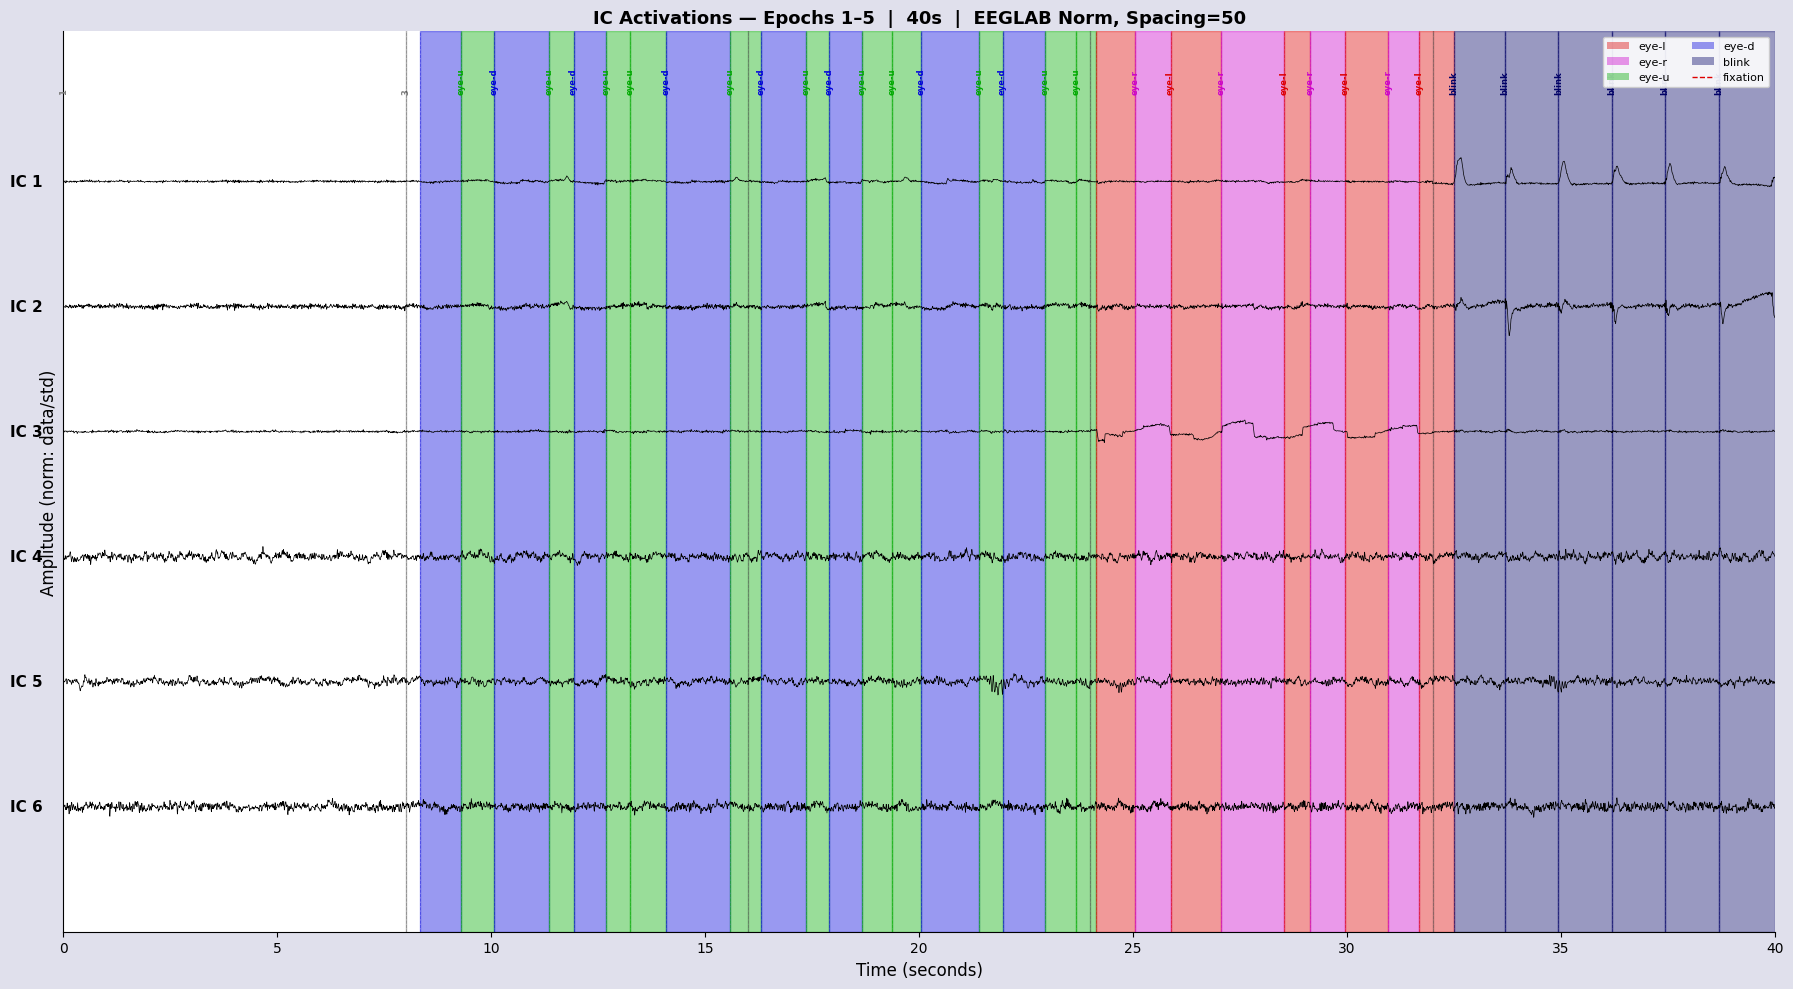

In [7]:
# ═══════════════════════════════════════════════════════════════
# STACKED IC PLOT — EEGLAB eegplot scaling (Norm + spacing)
# ═══════════════════════════════════════════════════════════════

# ── CONFIG ──
START_EPOCH = 0
N_EPOCHS    = 5
N_ICS       = 6
SPACING     = 50          # vertical offset between channel centres (eegplot 'spacing')

END_EPOCH   = START_EPOCH + N_EPOCHS
TOTAL_SAMPS = N_EPOCHS * pnts
epoch_dur   = pnts / srate
total_sec   = N_EPOCHS * epoch_dur

# ── Time axis (seconds) ──
t = np.arange(TOTAL_SAMPS) / srate

# ── CONCATENATE RAW IC ACTIVATIONS (already in µV) ──
ic_cat = np.concatenate(
    [ic_all[i] for i in range(START_EPOCH, END_EPOCH)], axis=1
)  # (58, N_EPOCHS*pnts) in µV

# ── EEGLAB Norm: divide each IC by its std (no mean subtraction) ──
ic_norm = np.zeros_like(ic_cat)
for i in range(ic_cat.shape[0]):
    s = np.std(ic_cat[i])
    ic_norm[i] = ic_cat[i] / s if s > 0 else ic_cat[i]

print(f'IC shape: {ic_cat.shape}  |  Time: 0–{total_sec:.0f}s  |  Spacing: {SPACING}')
for i in range(N_ICS):
    r = ic_cat[i]
    print(f'  IC{i+1}: raw µV [{np.min(r):.1f}, {np.max(r):.1f}]  |  std={np.std(r):.2f}  |  '
          f'norm [{np.min(ic_norm[i]):.2f}, {np.max(ic_norm[i]):.2f}]')

# ── BUILD EVENTS ──
window_start = START_EPOCH * pnts + 1
disp_events = []
for ev in events:
    ep = ev['epoch']
    if (START_EPOCH + 1) <= ep <= END_EPOCH:
        s = int(ev['latency'] - window_start)
        if 0 <= s < TOTAL_SAMPS:
            disp_events.append({'s': s, 't': s / srate, 'type': ev['type']})
disp_events.sort(key=lambda x: x['s'])

# ── COLORS ──
EVENT_COLORS = {
    'eye-l': '#DD0000', 'eye-r': '#CC00CC', 'eye-u': '#00AA00',
    'eye-d': '#0000DD', 'blink': '#000066', 'fixation': '#DD0000',
}
BG_EVENTS = {'eye-l', 'eye-r', 'eye-u', 'eye-d', 'blink'}

# ── BACKGROUND SPANS ──
spans = []
cur_color, cur_start, cur_type = None, 0.0, None
for ev in disp_events:
    if ev['type'] in BG_EVENTS:
        if cur_color is not None:
            spans.append((cur_start, ev['t'], cur_color, cur_type))
        cur_color = EVENT_COLORS[ev['type']]
        cur_type  = ev['type']
        cur_start = ev['t']
if cur_color is not None:
    spans.append((cur_start, total_sec, cur_color, cur_type))

# ── PLOT (eegplot: normalized data + spacing offset) ──
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#E0E0EC')
ax.set_facecolor('white')

# Background bands
for t0, t1, col, _ in spans:
    ax.axvspan(t0, t1, color=col, alpha=0.40, zorder=0)

# IC waveforms — y = norm_data + (N_ICS - i) * SPACING
for i in range(N_ICS):
    center = (N_ICS - i) * SPACING
    ax.plot(t, ic_norm[i] + center, lw=0.5, color='black', zorder=2)

# Event labels at top
label_y = (N_ICS + 0.7) * SPACING
prev_t = -1.0
for ev in disp_events:
    col = EVENT_COLORS.get(ev['type'], 'gray')
    ax.axvline(ev['t'], color=col, lw=0.6, ls='--', alpha=0.4, zorder=1)
    if ev['t'] - prev_t > 0.5:
        ax.text(ev['t'], label_y, ev['type'],
                rotation=90, fontsize=6, ha='center', va='bottom',
                color=col, fontweight='bold')
        prev_t = ev['t']

# IC labels on left
for i in range(N_ICS):
    center = (N_ICS - i) * SPACING
    ax.text(-total_sec * 0.012, center, f'IC {i+1}',
            fontsize=11, ha='right', va='center', fontweight='bold')

# Epoch boundaries
for k in range(1, N_EPOCHS):
    ax.axvline(k * epoch_dur, color='black', lw=1.0, ls='-', alpha=0.3, zorder=3)

# Axes
ax.set_xlim(0, total_sec)
ax.set_ylim(0, (N_ICS + 1.2) * SPACING)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude (norm: data/std)', fontsize=12)
ax.set_yticks([])
ax.set_title(
    f'IC Activations — Epochs {START_EPOCH+1}–{END_EPOCH}  |  {total_sec:.0f}s  |  '
    f'EEGLAB Norm, Spacing={SPACING}',
    fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor='#DD0000', alpha=0.4, label='eye-l'),
    Patch(facecolor='#CC00CC', alpha=0.4, label='eye-r'),
    Patch(facecolor='#00AA00', alpha=0.4, label='eye-u'),
    Patch(facecolor='#0000DD', alpha=0.4, label='eye-d'),
    Patch(facecolor='#000066', alpha=0.4, label='blink'),
    Line2D([0],[0], color='#DD0000', ls='--', lw=1, label='fixation'),
], loc='upper right', fontsize=8, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()

IC3 — 24s to 32s (samples 4800–6400)
  Raw µV  range: [-14.02, 14.49]
  Norm range:    [-4.44, 4.59]

Positive peaks (31):
  t=24.290s  |  norm= -3.104  |  raw=     -9.80 µV
  t=24.385s  |  norm= -0.806  |  raw=     -2.54 µV
  t=24.585s  |  norm= -1.171  |  raw=     -3.70 µV
  t=24.685s  |  norm= -1.330  |  raw=     -4.20 µV
  t=24.765s  |  norm=  0.113  |  raw=      0.36 µV
  t=25.245s  |  norm=  2.345  |  raw=      7.41 µV
  t=25.445s  |  norm=  2.692  |  raw=      8.50 µV
  t=25.645s  |  norm=  3.245  |  raw=     10.25 µV
  t=25.955s  |  norm= -1.060  |  raw=     -3.35 µV
  t=26.075s  |  norm= -0.828  |  raw=     -2.61 µV
  t=26.240s  |  norm= -0.862  |  raw=     -2.72 µV
  t=26.315s  |  norm= -0.880  |  raw=     -2.78 µV
  t=26.520s  |  norm= -2.755  |  raw=     -8.70 µV
  t=27.330s  |  norm=  3.878  |  raw=     12.25 µV
  t=27.455s  |  norm=  4.124  |  raw=     13.02 µV
  t=27.610s  |  norm=  4.589  |  raw=     14.49 µV
  t=27.695s  |  norm=  3.634  |  raw=     11.47 µV
  t=27.975

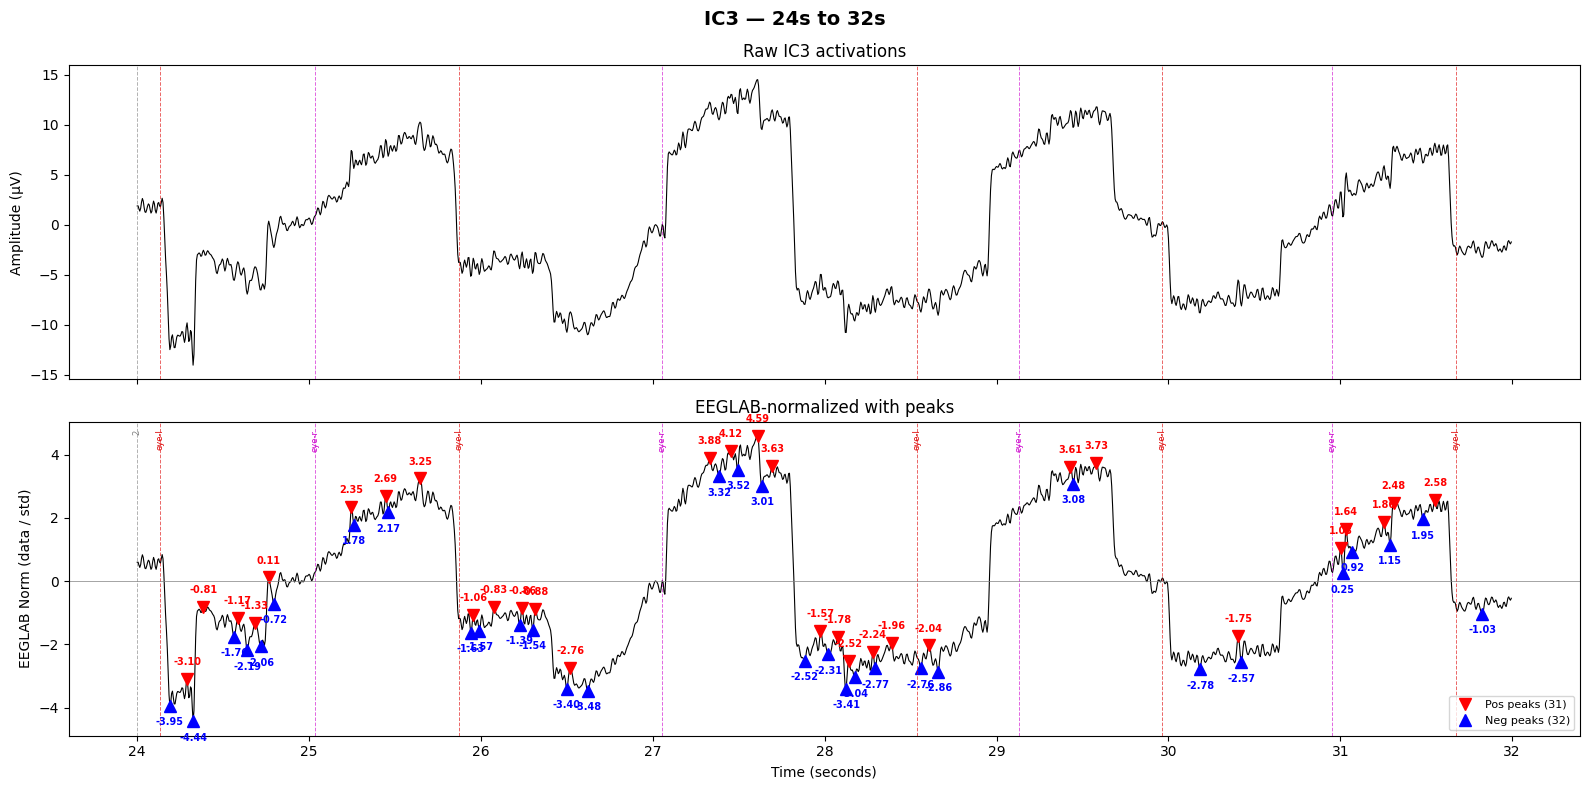

In [8]:
# ── IC3 Zoom: 24–32 seconds — find and label peaks ──
from scipy.signal import find_peaks

IC = 2  # 0-indexed → IC3
T_START, T_END = 24.0, 32.0

# Extract IC3 in the 24–32s window
s_start = int(T_START * srate)  # sample 4800
s_end   = int(T_END * srate)    # sample 6400
ic3_raw  = ic_cat[IC, s_start:s_end]       # raw µV
ic3_norm = ic_norm[IC, s_start:s_end]      # EEGLAB norm (data/std)
t_win    = np.arange(s_start, s_end) / srate  # time axis

# Find peaks on normalized data
pos_idx, pos_props = find_peaks(ic3_norm, prominence=0.5)
neg_idx, neg_props = find_peaks(-ic3_norm, prominence=0.5)

# Events in this window
win_events = [ev for ev in disp_events if T_START <= ev['t'] < T_END]

# ── Print peak values ──
print(f'IC3 — {T_START:.0f}s to {T_END:.0f}s (samples {s_start}–{s_end})')
print(f'  Raw µV  range: [{ic3_raw.min():.2f}, {ic3_raw.max():.2f}]')
print(f'  Norm range:    [{ic3_norm.min():.2f}, {ic3_norm.max():.2f}]')
print(f'\nPositive peaks ({len(pos_idx)}):')
for idx in pos_idx:
    print(f'  t={t_win[idx]:.3f}s  |  norm={ic3_norm[idx]:>7.3f}  |  raw={ic3_raw[idx]:>10.2f} µV')
print(f'\nNegative peaks ({len(neg_idx)}):')
for idx in neg_idx:
    print(f'  t={t_win[idx]:.3f}s  |  norm={ic3_norm[idx]:>7.3f}  |  raw={ic3_raw[idx]:>10.2f} µV')

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'IC3 — {T_START:.0f}s to {T_END:.0f}s', fontsize=14, fontweight='bold')

# Top: raw µV
ax1.plot(t_win, ic3_raw, lw=0.8, color='black')
ax1.set_ylabel('Amplitude (µV)')
ax1.set_title('Raw IC3 activations')
for ev in win_events:
    col = EVENT_COLORS.get(ev['type'], 'gray')
    ax1.axvline(ev['t'], color=col, ls='--', lw=0.7, alpha=0.6)

# Bottom: EEGLAB-normalized with peaks marked
ax2.plot(t_win, ic3_norm, lw=0.8, color='black')
ax2.plot(t_win[pos_idx], ic3_norm[pos_idx], 'rv', ms=8, label=f'Pos peaks ({len(pos_idx)})')
ax2.plot(t_win[neg_idx], ic3_norm[neg_idx], 'b^', ms=8, label=f'Neg peaks ({len(neg_idx)})')

# Annotate peaks
for idx in pos_idx:
    ax2.annotate(f'{ic3_norm[idx]:.2f}', (t_win[idx], ic3_norm[idx]),
                 textcoords='offset points', xytext=(0, 10),
                 fontsize=7, ha='center', color='red', fontweight='bold')
for idx in neg_idx:
    ax2.annotate(f'{ic3_norm[idx]:.2f}', (t_win[idx], ic3_norm[idx]),
                 textcoords='offset points', xytext=(0, -14),
                 fontsize=7, ha='center', color='blue', fontweight='bold')

# Event lines
for ev in win_events:
    col = EVENT_COLORS.get(ev['type'], 'gray')
    ax2.axvline(ev['t'], color=col, ls='--', lw=0.7, alpha=0.6)
    ax2.text(ev['t'], ax2.get_ylim()[1] * 0.95, ev['type'],
             rotation=90, fontsize=6, ha='center', va='top', color=col)

ax2.set_ylabel('EEGLAB Norm (data / std)')
ax2.set_xlabel('Time (seconds)')
ax2.set_title('EEGLAB-normalized with peaks')
ax2.legend(loc='lower right', fontsize=8)
ax2.axhline(0, color='gray', lw=0.5, ls='-')

plt.tight_layout()
plt.show()